# **Deep Learning:<br>Step-by-Step Fruit & Vegetable Image Recognition**

<table style="text-align:left;">
<tr>
<td style="vertical-align: top; padding-right: 20px;">
  <img src="https://github.com/user-attachments/assets/1311dc05-d9e9-4e77-8042-d84b3be545dd" alt="Foto Erlinda" width="150" style="border:none;"/>
</td>
<td style="vertical-align: top;">
  <h2 style="margin:0; text-align:left; font-size:23px;">By: Ir. Erlinda Gilberta Wibawa, S.T., M.T.</h2>
  <br>
  <p style="margin:0; text-align:left; font-size:7px;">
    <a href="https://www.instagram.com/erlinda_gilberta/?hl=en" target="_blank">@erlinda_gilberta</a>
  </p>
  <br>
  <h4 style="margin-top:5px; text-align:left; font-size:15px;">
    <em>Lecturer in Logistics Engineering,<br>
    Universitas Katolik Santo Agustinus Hippo,<br>
    West Kalimantan, Indonesia</em>
  </h4>
</td>
</tr>
</table>

> The ability of machines to see and recognize images has become a reality in the Industry 4.0 era, including in agriculture. Through Convolutional Neural Networks (CNN), computers can autonomously learn to identify objects in images, enabling smarter and more efficient agricultural practices.

> This tutorial demonstrates a step-by-step approach to using a CNN model for fruit and vegetable image recognition. Although simple, it helps to understand how a CNN model captures visual patterns such as shapes, colors, and textures, and uses them to classify images with increasing accuracy as the model trains.
> Basic knowledge of image recognition with CNNs can be further developed for agricultural applications. For example, more complex models could be used to:: 
>- Automatically sort fruits and vegetables, making the production process faster and more consistent..
>- Detect the quality of agricultural products, such as ripeness, damage, or plant diseases.
>- MSupport online sales systems by facilitating cataloging and product recognition from photos uploaded by farmers or vendors..
>By understanding how machine learning works for image recognition, it provides a real-world picture of how this technology can be applied to improve efficiency and quality in the agricultural sector..

>**Let's follow the coding steps & see how a CNN model can automatically recognize fruits and vegetables!**

<img src="https://raw.githubusercontent.com/erlindagilbertaw/MachineLearning/main/Image_Recognition.jpg" alt="Dataset" width="500"/>

### 📂**DATASET:**
<BR>https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition?select=test

## **LIBRARIES PREPARATION**

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## **1. TRAIN THE MODEL**

### 1.1. TRAINING DATASET PREPARATION

In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\PROJECT\MachineLearning\train',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(64,64),
    shuffle=True)

Found 3115 files belonging to 36 classes.


### 1.2. VALIDATION DATASET PREPARATION

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\PROJECT\MachineLearning\validation',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(64,64),
    shuffle=True)

Found 351 files belonging to 36 classes.


### 1.3. BUILD THE MODEL

<img src="https://raw.githubusercontent.com/erlindagilbertaw/MachineLearning/main/Image_Recognition_CNN.jpg" alt="Dataset" width="800"/>

>This model is a sequential CNN that extracts features from 64x64x3 images through multiple convolutional and pooling blocks. The first block uses 32 filters to capture basic features, while the second block uses 64 filters for more complex patterns, each followed by MaxPooling and Dropout to reduce dimensions and prevent overfitting. A Flatten layer then converts the feature maps into a 1D vector, which is processed by Dense layers to learn high-level patterns, with additional Dropout for regularization. The output layer has 36 neurons with softmax activation, producing class probabilities for accurate image classification.

In [20]:
# Create a sequential model: Initializes a CNN model where layers are added one after another
cnn = tf.keras.models.Sequential()

# Input layer:64x64 pixels with 3 color channels (RGB)
cnn.add(tf.keras.Input(shape=(64,64,3)))

# Convolutional Block 1:
# 32 filters, each 3x3 in size
# Padding='same' keeps output the same size as input
# Activation='relu' introduces non-linearity
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))

# Adds another Conv2D layer with 32 filters, ReLU activation
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))

# MaxPooling layer: reduces spatial dimensions by taking max value in each 2x2 window
# Strides=2 halves width and height of the feature map
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

# Dropout layer: randomly sets 25% of neurons to zero during training to prevent overfitting
cnn.add(tf.keras.layers.Dropout(0.25))

# Convolutional Block 2:
# Conv2D layers with 64 filters capture more complex features
# MaxPooling reduces spatial dimensions
# Dropout prevents overfitting
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Dropout(0.25))

# Flatten layer: converts 2D feature maps into a 1D vector to feed into dense layers
cnn.add(tf.keras.layers.Flatten())

# Dense (Fully Connected) layers:
# 512 neurons → 256 neurons
# ReLU activation learns higher-level patterns
cnn.add(tf.keras.layers.Dense(units=512,activation='relu'))
cnn.add(tf.keras.layers.Dense(units=256,activation='relu'))

# Dropout(0.5): randomly ignores 50% of neurons during training to avoid overfitting
cnn.add(tf.keras.layers.Dropout(0.5))

# Output layer:
# 36 units → each represents a class (e.g., different fruits or vegetables)
# Softmax activation → outputs probabilities summing to 1
cnn.add(tf.keras.layers.Dense(units=36,activation='softmax'))

### 1.4. COMPILING & TRAINING PHASE

>The CNN model is compiled using the Adam optimizer for efficient weight updates, with categorical crossentropy as the loss function suitable for multi-class classification, and accuracy as the evaluation metric. The model structure is summarized with cnn.summary() to show layers and parameters. Training is performed over 32 epochs using the training dataset, while the validation dataset evaluates performance after each epoch. The training_history object records loss and accuracy for each epoch, enabling analysis of the model’s learning progress.

In [21]:
# Compile the CNN model: prepares the model for training:
# optimizer='adam' → Adam optimizer adjusts the model weights efficiently during training.
# loss='categorical_crossentropy' → suitable loss function for multi-class classification (e.g., recognizing multiple types of fruits/vegetables).
# metrics=['accuracy'] → tracks the accuracy of the model during training and validation.
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
cnn.summary()

# Train the CNN model using the dataset:
# x=training_set → training images and labels
# validation_data=validation_set → validation images and labels used to evaluate model performance after each epoch
# epochs=32 → the model will iterate over the entire training dataset 32 times
# training_history → stores training metrics (loss, accuracy) for each epoch, useful for plotting learning curves
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=32)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,629,188 (25.29 MB)

 Trainable params: 6,629,188 (25.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32


98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - accuracy: 0.0299 - loss: 6.9044 - val_accuracy: 0.0285 - val_loss: 3.5829
Epoch 2/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.0324 - loss: 3.5823 - val_accuracy: 0.0370 - val_loss: 3.5810
Epoch 3/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.0360 - loss: 3.5641 - val_accuracy: 0.0769 - val_loss: 3.4393
Epoch 4/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.0562 - loss: 3.4915 - val_accuracy: 0.0684 - val_loss: 3.4502
Epoch 5/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.0687 - loss: 3.3662 - val_accuracy: 0.1054 - val_loss: 3.0834
Epoch 6/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.0918 - loss: 3.2583 - val_accuracy: 0.1738 - val_loss: 2.9598
Epoch 7/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.1303 - loss: 3.0484 - val_accuracy: 0.3020 - val_loss: 2.4708
Epoch 8/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 247ms/step - accuracy: 0.1894 - loss: 2.7980 - val_accuracy: 0.378

### 1.5. MODEL EVALUATION

>1. Training Accuracy = How well the model remembers the training data.
>- Measures how well the model learns from the data it was trained on.
>- Indicates whether the model is fitting the training data properly or underfitting.
>- However: high training accuracy alone is not enough, because the model might just “memorize” the data (overfitting) and fail on new data.
>2. Validation Accuracy = How well the model applies knowledge to unseen data.
>- Measures performance on data not seen during training (the validation set).
>- Shows the model’s ability to generalize patterns to new data.
>- If validation accuracy is much lower than training accuracy → a sign of overfitting.

>Comparing both helps identify:
>- Underfitting (both accuracies low)
>- Overfitting (training high, validation low)
>- Whether adjustments are needed, like more data, regularization, or model tuning.

In [22]:
# Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

# Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - accuracy: 0.9865 - loss: 0.0473
Training accuracy: 0.9865168333053589
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 446ms/step - accuracy: 0.9430 - loss: 0.2615
Validation accuracy: 0.9430199265480042


### 1.6. SAVE THE MODEL

>The trained CNN model is saved to trained_model.keras, and its training metrics (loss, accuracy, etc.) are recorded in training_history.history. These metrics are also saved to training_hist.json for later analysis or plotting learning curves without retraining.

In [23]:
cnn.save('trained_model.keras')

# Return dictionary of history
training_history.history

# Recording history in JSON
# Save the training history to a JSON file (training_hist.json)
# Useful for:
# Later analysis
# Plotting learning curves without retraining
# json.dump() converts the Python dictionary into a JSON format for storage
import json

with open('training_hist.json', 'w') as f:
    json.dump(training_history.history, f)  # <-- must be indented

print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### 1.7. MODEL ACCURACY CALCULATON

>After training, the model’s accuracy on the Validation Set is calculated and displayed as a percentage,
<BR>showing how well it performs on unseen data.
<BR>The Training Accuracy over all epochs is plotted in red to visualize how the model learns over time.
<BR>The Validation Accuracy is plotted in blue to track performance on unseen data alongside training progress.
<BR>These visualizations make it easy to identify learning trends and detect underfitting or overfitting.

Validation set Accuracy: 94.30199265480042 %


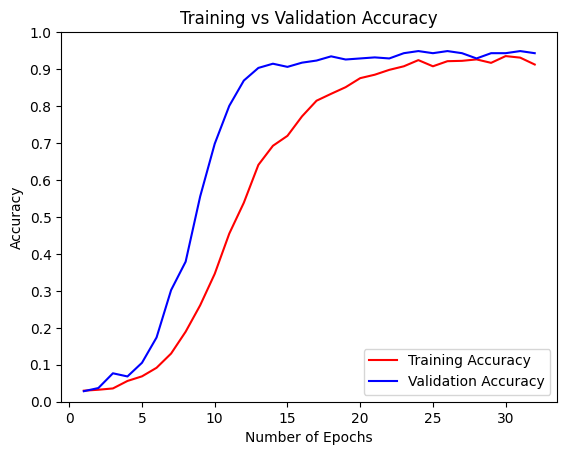

In [33]:
#Accuracy Calculation
print("Validation set Accuracy: {} %".format(training_history.history['val_accuracy'][-1]*100))

epochs = [i for i in range(1, 33)]

# Plot Training dan Validation Accuracy dalam satu grafik
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')

plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.show()

>At the beginning of training, both accuracies were low because the model was just starting to learn the features from the dataset. As the number of epochs increased, accuracy improved significantly, indicating that the model successfully captured important patterns and features from the images. The training accuracy gradually rose, approaching 0.9 by the final epoch, showing that the model was able to recognize images in the training dataset effectively.

>The validation accuracy followed a similar pattern, approaching the training accuracy, which indicates that the model has good generalization ability and has not experienced significant overfitting. By the end of training, the validation set accuracy reached 94.30%, demonstrating that the model performs very well on unseen data. Both metrics began to stagnate or plateau towards the end of training, indicating that the model had reached its maximum performance for this dataset.

>Overall, this graph demonstrates that the CNN model is capable of learning and recognizing objects in images effectively, with consistent results between training and validation data, making it ready for prediction on new images.

## **2. TEST THE MODEL**

### 2.1. TESTING DATASET PREPARATION

In [25]:
testing_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\PROJECT\MachineLearning\test',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(64,64),
    shuffle=True
)

Found 359 files belonging to 36 classes.


### 2.2. MODEL LOADING

In [26]:
# load the model
cnn = tf.keras.models.load_model('D:\PROJECT\MachineLearning/trained_model.h5')

# Return to compile
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

### 2.3. TEST FOR A SINGLE IMAGE

>Testing the model on a single image first serves as a quick verification that the trained model and prediction pipeline are working correctly. It ensures that image preprocessing, input shape, and class prediction are handled as expected. This step helps identify potential issues, such as incorrect image size, color format, or array conversion, before evaluating the model on a full dataset. Essentially, it is a fast and safe way to confirm the model is ready for large-scale testing.

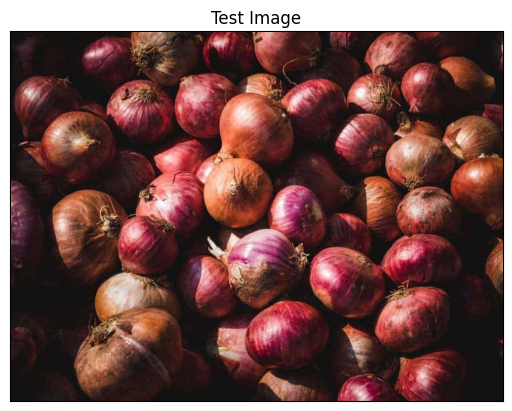

In [27]:
import cv2
image_path = r'D:\PROJECT\MachineLearning\test\onion\Image_3.jpg'

# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB

# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

### 2.4. TEST THE MODEL

>The trained CNN model is used to predict the class of a test image. The image is resized to 64x64 pixels to match the model's training input, then converted to a NumPy array and wrapped in a batch of size 1 since Keras models always accept batched input. The model generates predictions in the form of probabilities for each class, and the class with the highest probability is selected using np.argmax() as the final prediction. The image is displayed along with its class prediction, allowing us to immediately visually verify whether the model correctly recognizes the object.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
[[1.36126494e-06 3.57470886e-10 3.92449406e-09 1.88870555e-12
  5.18998940e-15 3.62865515e-10 7.03631728e-12 3.24562317e-13
  1.11176970e-10 4.33274458e-11 1.02444744e-16 4.20002273e-08
  5.86339688e-08 9.26468591e-09 1.83577742e-09 1.43529910e-11
  2.31524598e-13 2.79433282e-10 1.93680758e-14 1.30747540e-11
  9.99983907e-01 2.96106406e-09 9.59443878e-06 7.89966148e-10
  1.82696579e-15 3.00075798e-11 6.83987196e-07 3.75018067e-06
  1.07975115e-10 1.01440342e-07 4.29169550e-18 2.22801829e-11
  5.23908795e-07 1.35240874e-10 1.36061198e-08 8.54925126e-13]]
20


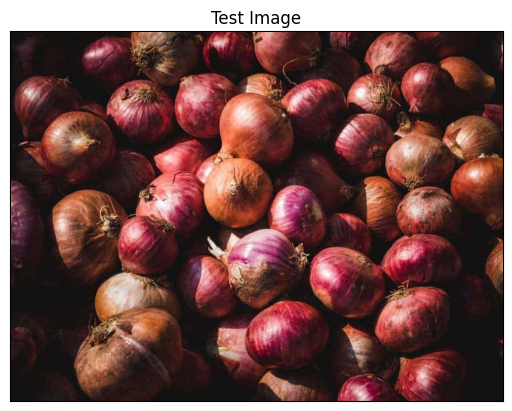

It's a onion


In [28]:
# Load the test image from the given path
# target_size=(64,64) ensures the image matches the input size of the CNN used during training
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(64,64))

# Convert image to a NumPy array: required format for CNN input
# np.array([input_arr]) wraps the single image into a batch of size 1 because Keras models expect input batches
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])

# Make a prediction using the trained CNN model
# predictions contains probabilities for each class
# Example output: [0.01, 0.02, 0.85, ...] → each value corresponds to a class
predictions = cnn.predict(input_arr)
print(predictions)

# Find the class with the highest probability
# np.argmax() returns the index of the predicted class
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

#Image prediction result
print("It's an {}".format(testing_set.class_names[result_index]))